# Nobel Prize Data Analysis and Visualization

This project analyzes Nobel Prize data to uncover trends in winner age, category distribution, and gender representation over time.

## Project Objectives

This analysis aims to answer the following questions:

- What is the average age of Nobel Prize winners at the time of receiving the award?
- How does winning age vary across categories?
- How has the proportion of female winners changed over time?
- Which categories and countries are most represented?

In [12]:
!pip install kagglehub


   ---------------------------------------- 0/2 [kagglesdk]
   -------------------- ------------------- 1/2 [kagglehub]
   ---------------------------------------- 2/2 [kagglehub]



In [14]:
import kagglehub
import pandas as pd
import os

path = kagglehub.dataset_download("nobelfoundation/nobel-laureates")

print("Dataset path:", path)

files = os.listdir(path)
print("Files in dataset:", files)

csv_file = [f for f in files if f.endswith(".csv")][0]

file_path = os.path.join(path, csv_file)

nobel = pd.read_csv(file_path)

nobel.columns = nobel.columns.str.strip().str.lower().str.replace(" ", "_")

nobel.head()

Dataset path: C:\Users\User\.cache\kagglehub\datasets\nobelfoundation\nobel-laureates\versions\1
Files in dataset: ['archive.csv']


,year,category,prize,motivation,prize_share,laureate_id,laureate_type,full_name,birth_date,birth_city,birth_country,sex,organization_name,organization_city,organization_country,death_date,death_city,death_country
0,1901,Chemistry,The Nobel Prize in Chemistry 1901,"""in recognition of the extraordinary services ...",1/1,160,Individual,Jacobus Henricus van 't Hoff,1852-08-30,Rotterdam,Netherlands,Male,Berlin University,Berlin,Germany,1911-03-01,Berlin,Germany
1,1901,Literature,The Nobel Prize in Literature 1901,"""in special recognition of his poetic composit...",1/1,569,Individual,Sully Prudhomme,1839-03-16,Paris,France,Male,NaN,NaN,NaN,1907-09-07,Châtenay,France
2,1901,Medicine,The Nobel Prize in Physiology or Medicine 1901,"""for his work on serum therapy, especially its...",1/1,293,Individual,Emil Adolf von Behring,1854-03-15,Hansdorf (Lawice),Prussia (Poland),Male,Marburg University,Marburg,Germany,1917-03-31,Marburg,Germany
3,1901,Peace,The Nobel Peace Prize 1901,NaN,1/2,462,Individual,Jean Henry Dunant,1828-05-08,Geneva,Switzerland,Male,NaN,NaN,NaN,1910-10-30,Heiden,Switzerland
4,1901,Peace,The Nobel Peace Prize 1901,NaN,1/2,463,Individual,Frédéric Passy,1822-05-20,Paris,France,Male,NaN,NaN,NaN,1912-06-12,Paris,France


In [15]:
print(nobel.shape)
print(nobel.info())

(969, 18)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 969 entries, 0 to 968
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   year                  969 non-null    int64 
 1   category              969 non-null    object
 2   prize                 969 non-null    object
 3   motivation            881 non-null    object
 4   prize_share           969 non-null    object
 5   laureate_id           969 non-null    int64 
 6   laureate_type         969 non-null    object
 7   full_name             969 non-null    object
 8   birth_date            940 non-null    object
 9   birth_city            941 non-null    object
 10  birth_country         943 non-null    object
 11  sex                   943 non-null    object
 12  organization_name     722 non-null    object
 13  organization_city     716 non-null    object
 14  organization_country  716 non-null    object
 15  death_date            617 non-

In [16]:
nobel.isnull().sum().sort_values(ascending=False)

death_city              370
death_country           364
death_date              352
organization_country    253
organization_city       253
organization_name       247
motivation               88
birth_date               29
birth_city               28
birth_country            26
sex                      26
category                  0
full_name                 0
laureate_type             0
laureate_id               0
prize_share               0
prize                     0
year                      0
dtype: int64

In [21]:
print(nobel.columns)

Index(['year', 'category', 'prize', 'motivation', 'prize_share', 'laureate_id',
       'laureate_type', 'full_name', 'birth_date', 'birth_city',
       'birth_country', 'sex', 'organization_name', 'organization_city',
       'organization_country', 'death_date', 'death_city', 'death_country'],
      dtype='object')


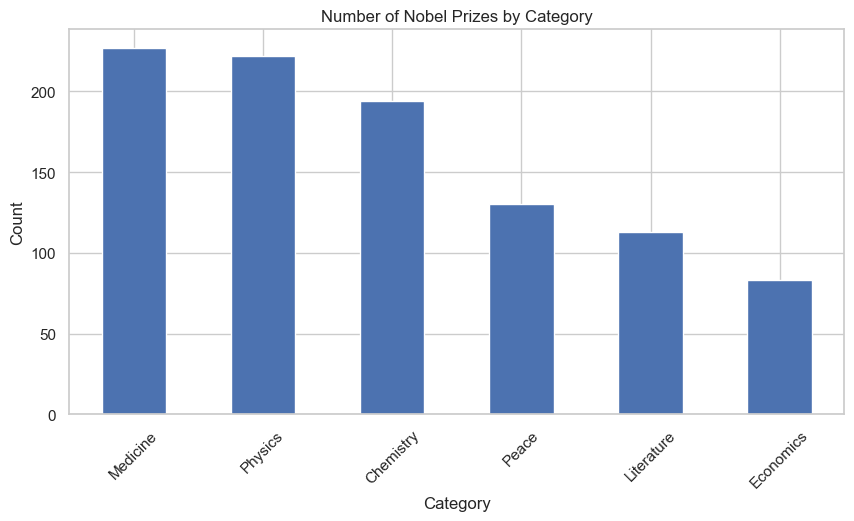

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
nobel["category"].value_counts().plot(kind="bar")
plt.title("Number of Nobel Prizes by Category")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

## Age Calculation

We calculate the age of winners at the time of receiving the Nobel Prize.

In [19]:
nobel["birth_date"] = pd.to_datetime(nobel["birth_date"], errors="coerce")
nobel["death_date"] = pd.to_datetime(nobel["death_date"], errors="coerce")

In [25]:
nobel["winning_age"] = nobel["year"] - nobel["birth_date"].dt.year
nobel[["full_name", "year", "birth_date", "winning_age"]].head()

,full_name,year,birth_date,winning_age
0,Jacobus Henricus van 't Hoff,1901,1852-08-30,49.0
1,Sully Prudhomme,1901,1839-03-16,62.0
2,Emil Adolf von Behring,1901,1854-03-15,47.0
3,Jean Henry Dunant,1901,1828-05-08,73.0
4,Frédéric Passy,1901,1822-05-20,79.0


In [27]:
nobel["winning_age"].describe()

count    938.000000
mean      59.484009
std       12.377220
min       17.000000
25%       50.000000
50%       60.000000
75%       69.000000
max       90.000000
Name: winning_age, dtype: float64

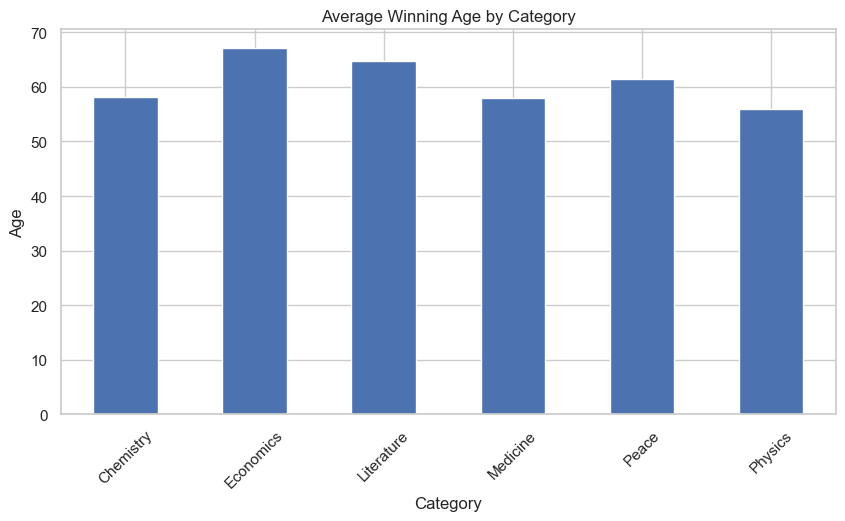

In [29]:
avg_age_by_category = nobel.groupby("category")["winning_age"].mean()

plt.figure(figsize=(10,5))
avg_age_by_category.plot(kind="bar")
plt.title("Average Winning Age by Category")
plt.xlabel("Category")
plt.ylabel("Age")
plt.xticks(rotation=45)
plt.show()

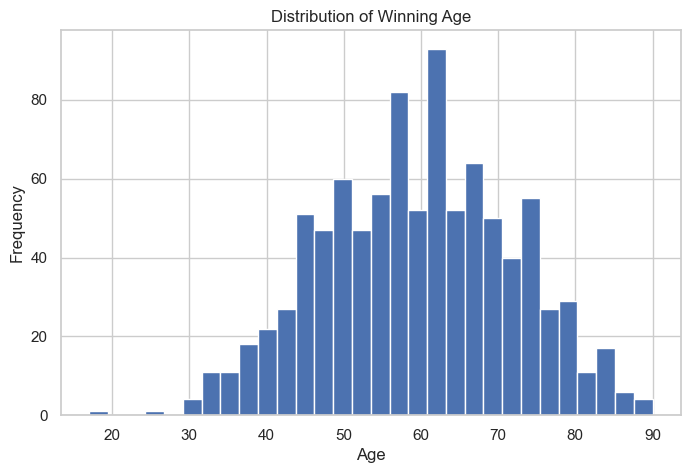

In [33]:
nobel_clean = nobel.dropna(subset=["winning_age"])

plt.figure(figsize=(8,5))
plt.hist(nobel_clean["winning_age"], bins=30)
plt.title("Distribution of Winning Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

## Death Age Distribution by Category

In [36]:
nobel["death_age"] = nobel["death_date"].dt.year - nobel["birth_date"].dt.year
nobel_clean = nobel.dropna(subset=["death_age"])

In [37]:
avg_death_age = nobel_clean.groupby("category")["death_age"].mean()

print(avg_death_age.sort_values())

category
Peace         77.915493
Chemistry     78.245902
Literature    79.281250
Physics       79.427481
Medicine      81.279221
Economics     85.738095
Name: death_age, dtype: float64


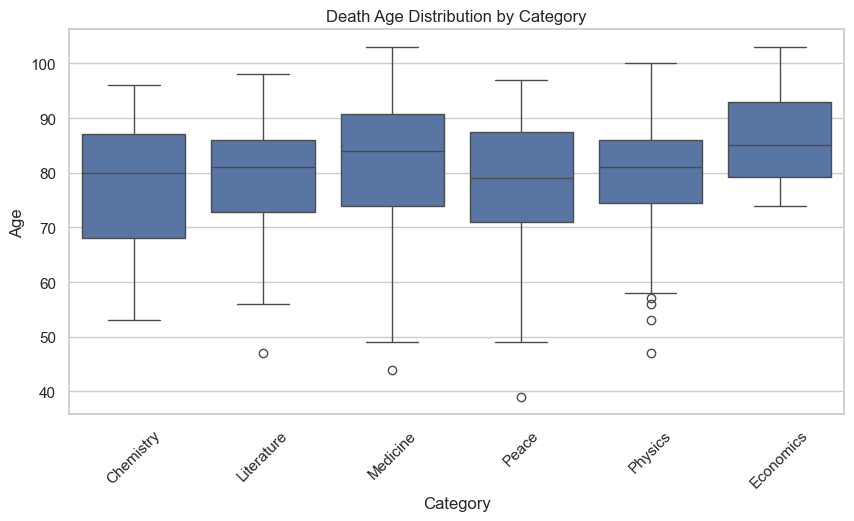

In [38]:
import seaborn as sns

plt.figure(figsize=(10,5))
sns.boxplot(data=nobel_clean, x="category", y="death_age")

plt.title("Death Age Distribution by Category")
plt.xlabel("Category")
plt.ylabel("Age")
plt.xticks(rotation=45)
plt.show()

## Gender Distribution Over Decades

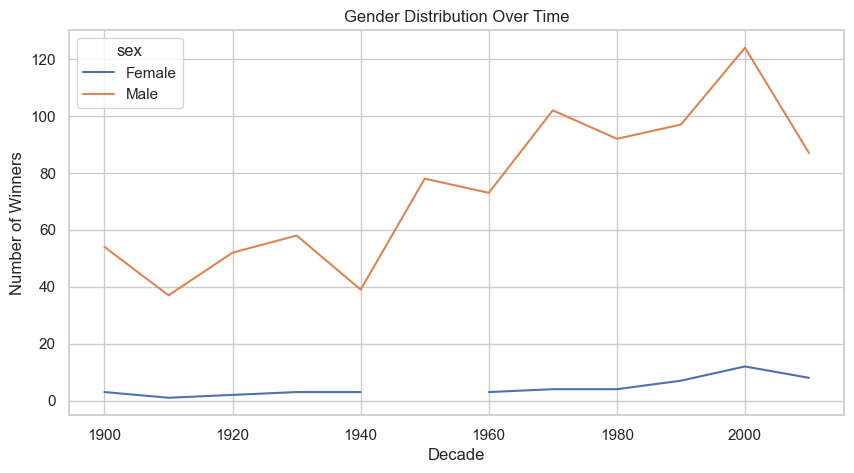

In [31]:
nobel["decade"] = (nobel["year"] // 10) * 10

gender_trend = nobel.groupby(["decade", "sex"]).size().unstack()

gender_trend.plot(figsize=(10,5))
plt.title("Gender Distribution Over Time")
plt.xlabel("Decade")
plt.ylabel("Number of Winners")
plt.show()

### Top 10 Countries of Winners

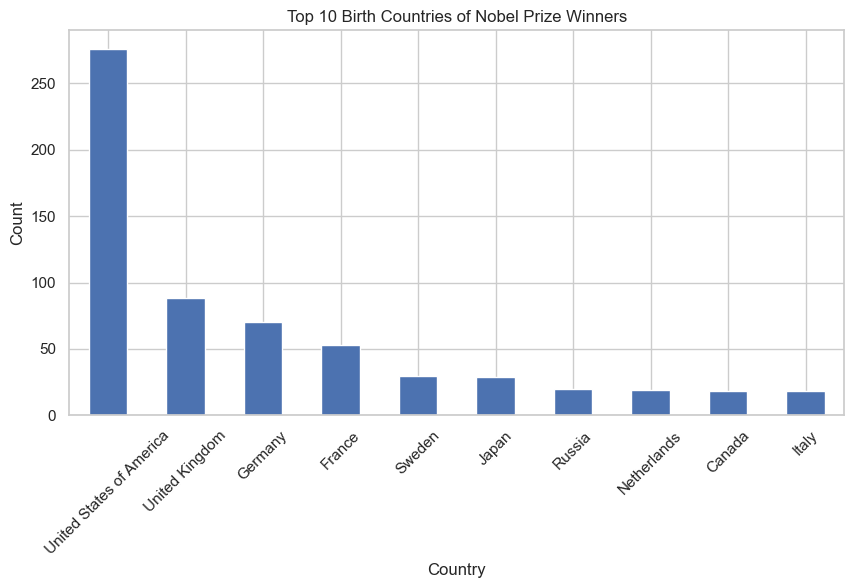

In [32]:
top_countries = nobel["birth_country"].value_counts().head(10)

plt.figure(figsize=(10,5))
top_countries.plot(kind="bar")
plt.title("Top 10 Birth Countries of Nobel Prize Winners")
plt.xlabel("Country")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

## Insight

The initial hypothesis suggested that Nobel Prize winners in Physics might have shorter lifespans compared to other categories.

However, the analysis contradicts this assumption. The results indicate that physicists do not exhibit a noticeably lower average death age.

This outcome emphasizes the importance of relying on data rather than intuition, demonstrating how empirical analysis can challenge preconceived ideas.